# Lambda Preprocessing Pipeline - Data Analysis
**Purpose**: Analyze preprocessing outputs to validate data quality, distribution, and completeness

**Sections**:
1. Setup and Data Loading
2. Overall Pipeline Metrics
3. Text Features Analysis
4. Image Features Analysis
5. Structured Features Analysis
6. Multimodal Completeness
7. Quality Checks and Validation
8. Summary Report

## 1. Setup and Data Loading

In [99]:
import pandas as pd
import numpy as np
import json
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [100]:
# Configuration
# Lambda GPU instance paths (absolute)
OUTPUT_DIR = Path('/home/ubuntu/mimic-cxr-validation/step2_preprocessing/output/validation_200/train')
COHORT_PATH = Path('/home/ubuntu/mimic-cxr-validation/step2_preprocessing/cohorts/validation_subset_200_with_reports.csv')
STATS_PATH = Path('/home/ubuntu/mimic-cxr-validation/step2_preprocessing/output/validation_200/train/processing_stats.json')

# Verify paths exist and show modification times
if OUTPUT_DIR.exists():
    print(f"✅ Output directory found: {OUTPUT_DIR}")
    print(f"   - Images: {len(list((OUTPUT_DIR / 'images').glob('*.pt')))} files")
    print(f"   - Text: {len(list((OUTPUT_DIR / 'text_features').glob('*.pt')))} files")
    print(f"   - Structured: {len(list((OUTPUT_DIR / 'structured_features').glob('*.json')))} files")
    print(f"   - Metadata: {len(list((OUTPUT_DIR / 'metadata').glob('*.json')))} files")
    
    # Check when files were last modified
    import os
    from datetime import datetime
    structured_files = list((OUTPUT_DIR / 'structured_features').glob('*.json'))
    if structured_files:
        latest_file = max(structured_files, key=lambda p: os.path.getmtime(p))
        mod_time = datetime.fromtimestamp(os.path.getmtime(latest_file))
        print(f"\n   📅 Latest structured file modified: {mod_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"      File: {latest_file.name}")
else:
    print(f"⚠️  Output directory not found: {OUTPUT_DIR}")
    print("   Please adjust OUTPUT_DIR to point to your preprocessing outputs")

✅ Output directory found: /home/ubuntu/mimic-cxr-validation/step2_preprocessing/output/validation_200/train
   - Images: 200 files
   - Text: 200 files
   - Structured: 200 files
   - Metadata: 200 files

   📅 Latest structured file modified: 2025-11-24 01:21:39
      File: s16043637_study57880955.json


In [101]:
# Load cohort
if COHORT_PATH.exists():
    cohort = pd.read_csv(COHORT_PATH)
    print(f"✅ Cohort loaded: {len(cohort)} samples")
    print(f"   Columns: {list(cohort.columns[:10])}...")
else:
    print(f"⚠️  Cohort file not found: {COHORT_PATH}")
    cohort = None

✅ Cohort loaded: 200 samples
   Columns: ['subject_id', 'study_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity']...


In [102]:
# Load processing statistics
if STATS_PATH.exists():
    with open(STATS_PATH, 'r') as f:
        stats = json.load(f)
    print("✅ Processing statistics loaded")
    print(json.dumps(stats.get('statistics', {}), indent=2))
else:
    print(f"⚠️  Statistics file not found: {STATS_PATH}")
    stats = None

✅ Processing statistics loaded
{
  "total_samples": 10,
  "processed": 10,
  "failed": 0,
  "image_errors": 0,
  "structured_errors": 0,
  "text_errors": 0,
  "avg_processing_time": 4.152746700000001,
  "image_success_rate": 1.0,
  "structured_success_rate": 1.0,
  "text_success_rate": 1.0
}


## 2. Overall Pipeline Metrics

In [103]:
# Collect all sample metadata
metadata_dir = OUTPUT_DIR / 'metadata'
all_metadata = []

for meta_file in sorted(metadata_dir.glob('*.json')):
    with open(meta_file, 'r') as f:
        all_metadata.append(json.load(f))

print(f"Loaded metadata for {len(all_metadata)} samples")

# Extract error information
samples_with_errors = [m for m in all_metadata if len(m.get('errors', [])) > 0]
error_free_samples = [m for m in all_metadata if len(m.get('errors', [])) == 0]

print(f"\n📊 Overall Success Rates:")
print(f"   Total samples: {len(all_metadata)}")
print(f"   Error-free: {len(error_free_samples)} ({len(error_free_samples)/len(all_metadata)*100:.1f}%)")
print(f"   With errors: {len(samples_with_errors)} ({len(samples_with_errors)/len(all_metadata)*100:.1f}%)")

Loaded metadata for 200 samples

📊 Overall Success Rates:
   Total samples: 200
   Error-free: 200 (100.0%)
   With errors: 0 (0.0%)


In [104]:
# Analyze error types
error_types = Counter()
for meta in samples_with_errors:
    for error in meta.get('errors', []):
        # Extract error type from error message
        error_type = error.split(':')[0] if ':' in error else error
        error_types[error_type] += 1

print("\n🔍 Error Type Distribution:")
for error_type, count in error_types.most_common():
    print(f"   {error_type}: {count} occurrences")

# Visualize
if error_types:
    fig, ax = plt.subplots(figsize=(10, 5))
    error_df = pd.DataFrame(error_types.most_common(), columns=['Error Type', 'Count'])
    sns.barplot(data=error_df, x='Count', y='Error Type', ax=ax)
    ax.set_title('Error Type Distribution')
    plt.tight_layout()
    plt.show()


🔍 Error Type Distribution:


## 3. Text Features Analysis

In [105]:
# Load all text features
text_dir = OUTPUT_DIR / 'text_features'
text_features = []

for text_file in sorted(text_dir.glob('*.pt')):
    data = torch.load(text_file)
    text_features.append({
        'file': text_file.stem,
        'summary': data.get('summary', ''),
        'num_tokens': data['tokens']['num_tokens'] if 'tokens' in data and 'num_tokens' in data['tokens'] else len(data.get('tokens', {}).get('input_ids', [])),
        'num_entities': data.get('num_entities', 0),
        'entities': data.get('entities', [])
    })

text_df = pd.DataFrame(text_features)
print(f"✅ Loaded {len(text_df)} text features")
print(f"\n📊 Text Statistics:")
print(text_df[['num_tokens', 'num_entities']].describe())

✅ Loaded 200 text features

📊 Text Statistics:
       num_tokens  num_entities
count  200.000000    200.000000
mean    79.390000      1.280000
std     33.492786      1.130482
min      0.000000      0.000000
25%     87.000000      1.000000
50%     93.500000      1.000000
75%     94.000000      2.000000
max    165.000000     10.000000


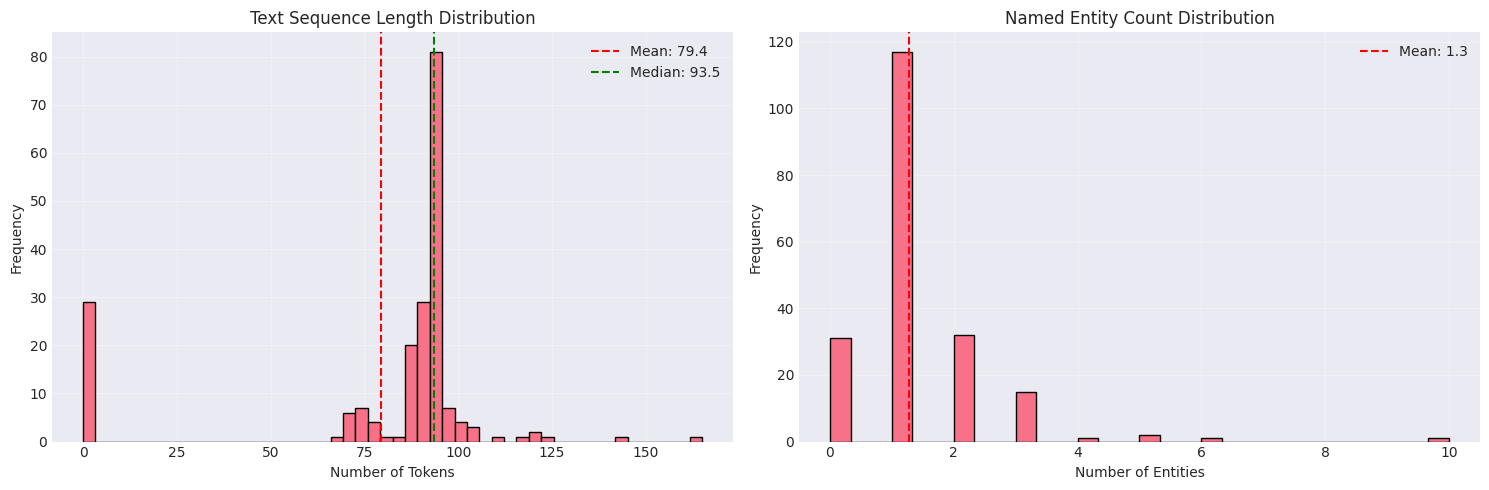


📈 Text Coverage:
   Samples with tokens > 2: 171 (85.5%)
   Samples with entities: 169 (84.5%)
   Empty summaries: 29 (14.5%)


In [106]:
# Text sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Token count distribution
axes[0].hist(text_df['num_tokens'], bins=50, edgecolor='black')
axes[0].axvline(text_df['num_tokens'].mean(), color='red', linestyle='--', label=f'Mean: {text_df["num_tokens"].mean():.1f}')
axes[0].axvline(text_df['num_tokens'].median(), color='green', linestyle='--', label=f'Median: {text_df["num_tokens"].median():.1f}')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Sequence Length Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Entity count distribution
axes[1].hist(text_df['num_entities'], bins=30, edgecolor='black')
axes[1].axvline(text_df['num_entities'].mean(), color='red', linestyle='--', label=f'Mean: {text_df["num_entities"].mean():.1f}')
axes[1].set_xlabel('Number of Entities')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Named Entity Count Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Text Coverage:")
print(f"   Samples with tokens > 2: {(text_df['num_tokens'] > 2).sum()} ({(text_df['num_tokens'] > 2).sum()/len(text_df)*100:.1f}%)")
print(f"   Samples with entities: {(text_df['num_entities'] > 0).sum()} ({(text_df['num_entities'] > 0).sum()/len(text_df)*100:.1f}%)")
print(f"   Empty summaries: {(text_df['summary'] == '').sum()} ({(text_df['summary'] == '').sum()/len(text_df)*100:.1f}%)")

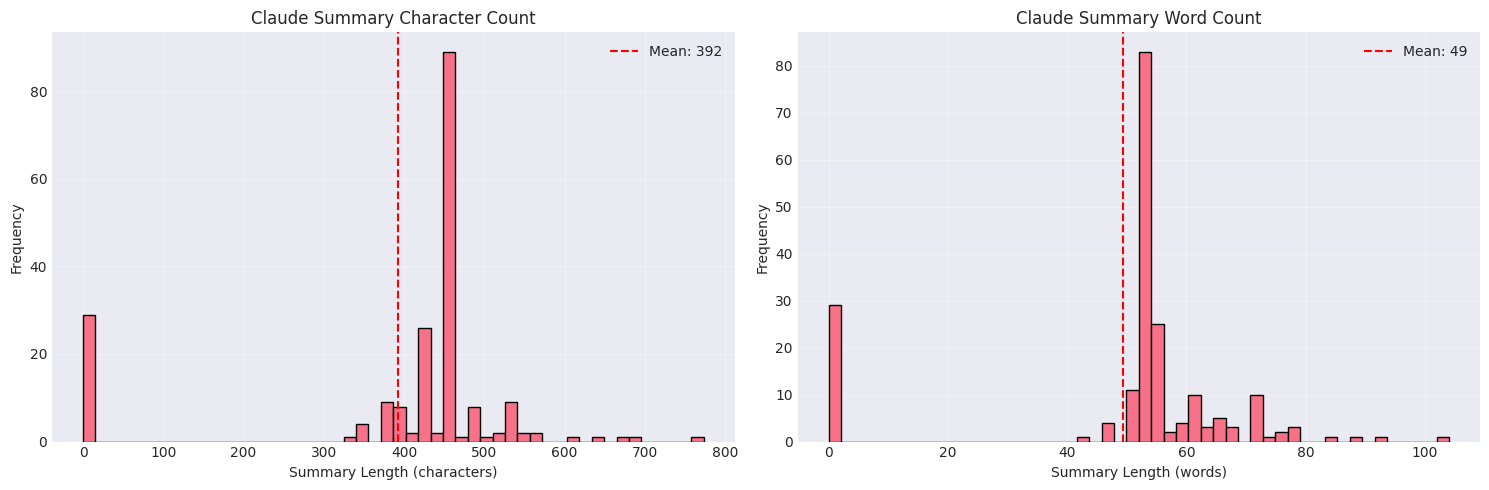

In [107]:
# Summary length analysis
text_df['summary_length'] = text_df['summary'].str.len()
text_df['summary_word_count'] = text_df['summary'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character count
axes[0].hist(text_df['summary_length'], bins=50, edgecolor='black')
axes[0].axvline(text_df['summary_length'].mean(), color='red', linestyle='--', label=f'Mean: {text_df["summary_length"].mean():.0f}')
axes[0].set_xlabel('Summary Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Claude Summary Character Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Word count
axes[1].hist(text_df['summary_word_count'].dropna(), bins=50, edgecolor='black')
axes[1].axvline(text_df['summary_word_count'].mean(), color='red', linestyle='--', label=f'Mean: {text_df["summary_word_count"].mean():.0f}')
axes[1].set_xlabel('Summary Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Claude Summary Word Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [108]:
# Sample summaries
print("\n📝 Sample Claude Summaries:")
print("=" * 80)
for i, row in text_df[text_df['summary_length'] > 0].sample(min(5, len(text_df))).iterrows():
    print(f"\nSample {row['file']}:")
    print(f"Tokens: {row['num_tokens']}, Entities: {row['num_entities']}")
    print(f"Summary: {row['summary'][:200]}..." if len(row['summary']) > 200 else f"Summary: {row['summary']}")
    print("-" * 80)


📝 Sample Claude Summaries:

Sample s12753312_study51783048:
Tokens: 94, Entities: 1
Summary: **Clinical Summary:**

The chest X-ray demonstrates no acute cardiopulmonary process. No specific clinical information regarding the patient's chief complaint, symptoms, medical history, physical exam...
--------------------------------------------------------------------------------

Sample s15375131_study53118977:
Tokens: 94, Entities: 1
Summary: **Clinical Summary:**

The chest X-ray demonstrates no acute cardiopulmonary process. No specific clinical information regarding the patient's chief complaint, symptoms, medical history, physical exam...
--------------------------------------------------------------------------------

Sample s19394918_study56865680:
Tokens: 87, Entities: 2
Summary: **Clinical Summary:**

The chest X-ray demonstrates no evidence of acute cardiopulmonary process. No specific patient symptoms, medical history, physical exam findings, vital signs, or laboratory abno...


## 4. Image Features Analysis

In [109]:
# Load image features
image_dir = OUTPUT_DIR / 'images'
image_features = []

for image_file in sorted(image_dir.glob('*.pt')):
    try:
        img = torch.load(image_file)
        image_features.append({
            'file': image_file.stem,
            'shape': tuple(img.shape),
            'channels': img.shape[0] if len(img.shape) > 0 else 0,
            'height': img.shape[1] if len(img.shape) > 1 else 0,
            'width': img.shape[2] if len(img.shape) > 2 else 0,
            'size_mb': img.element_size() * img.nelement() / (1024 * 1024)
        })
    except Exception as e:
        print(f"Error loading {image_file}: {e}")

image_df = pd.DataFrame(image_features)
print(f"✅ Loaded {len(image_df)} image features")
print(f"\n📊 Image Statistics:")
print(image_df[['channels', 'height', 'width', 'size_mb']].describe())

✅ Loaded 200 image features

📊 Image Statistics:
       channels       height        width     size_mb
count     200.0   200.000000   200.000000  200.000000
mean        1.0  2964.750000  2608.395000   29.400374
std         0.0   208.374994   194.523484    1.509752
min         1.0  1688.000000  1791.000000   11.532623
25%         1.0  3056.000000  2544.000000   29.657227
50%         1.0  3056.000000  2544.000000   29.657227
75%         1.0  3056.000000  2544.000000   29.657227
max         1.0  3056.000000  3056.000000   29.657227



🖼️  Image Shape Distribution:
   (1, 3056, 2544): 152 images (76.0%)
   (1, 2544, 3056): 27 images (13.5%)
   (1, 3056, 2504): 2 images (1.0%)
   (1, 2865, 2544): 1 images (0.5%)
   (1, 3028, 2544): 1 images (0.5%)
   (1, 2862, 2381): 1 images (0.5%)
   (1, 2860, 2484): 1 images (0.5%)
   (1, 3056, 2537): 1 images (0.5%)
   (1, 3056, 2512): 1 images (0.5%)
   (1, 2843, 2237): 1 images (0.5%)
   (1, 3056, 2536): 1 images (0.5%)
   (1, 3012, 2544): 1 images (0.5%)
   (1, 3011, 2428): 1 images (0.5%)
   (1, 3056, 2520): 1 images (0.5%)
   (1, 1688, 1791): 1 images (0.5%)
   (1, 2544, 3036): 1 images (0.5%)
   (1, 2637, 2417): 1 images (0.5%)
   (1, 3056, 2524): 1 images (0.5%)
   (1, 3056, 2320): 1 images (0.5%)
   (1, 3056, 2516): 1 images (0.5%)
   (1, 2540, 3056): 1 images (0.5%)
   (1, 2356, 2544): 1 images (0.5%)


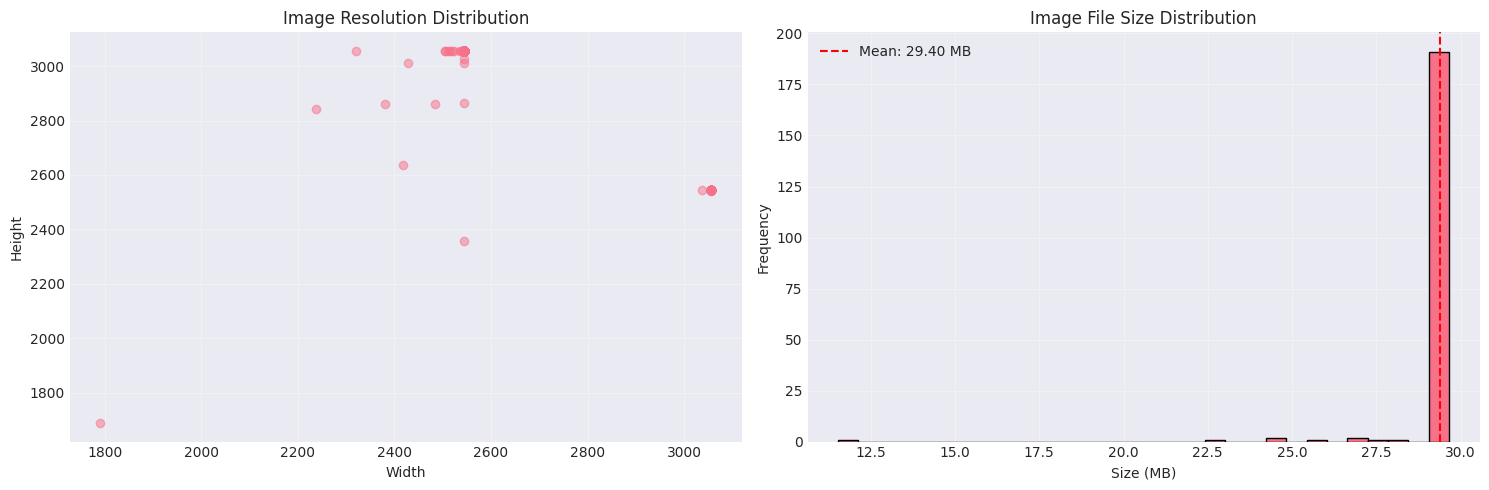

In [110]:
# Image shape distribution
shape_counts = image_df['shape'].value_counts()

print(f"\n🖼️  Image Shape Distribution:")
for shape, count in shape_counts.items():
    print(f"   {shape}: {count} images ({count/len(image_df)*100:.1f}%)")

# Visualize image sizes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Resolution distribution
axes[0].scatter(image_df['width'], image_df['height'], alpha=0.5)
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Height')
axes[0].set_title('Image Resolution Distribution')
axes[0].grid(True, alpha=0.3)

# File size distribution
axes[1].hist(image_df['size_mb'], bins=30, edgecolor='black')
axes[1].axvline(image_df['size_mb'].mean(), color='red', linestyle='--', label=f'Mean: {image_df["size_mb"].mean():.2f} MB')
axes[1].set_xlabel('Size (MB)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Image File Size Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Structured Features Analysis

In [111]:
# Load structured features
structured_dir = OUTPUT_DIR / 'structured_features'
structured_features = []

for struct_file in sorted(structured_dir.glob('*.json')):
    with open(struct_file, 'r') as f:
        data = json.load(f)
        structured_features.append({
            'file': struct_file.stem,
            'data': data
        })

print(f"✅ Loaded {len(structured_features)} structured feature files")

✅ Loaded 200 structured feature files


In [112]:
# Analyze DICOM metadata coverage (first 10 fields)
dicom_fields = [
    'view_pa', 'view_ap', 'view_lateral',
    'orientation_erect', 'orientation_recumbent', 'orientation_unknown',
    'is_portable', 'image_rows_normalized', 'image_cols_normalized', 'num_views'
]

dicom_coverage = {field: 0 for field in dicom_fields}
dicom_values = {field: [] for field in dicom_fields}

for item in structured_features:
    data = item['data']
    for field in dicom_fields:
        if field in data and data[field] is not None:
            dicom_coverage[field] += 1
            dicom_values[field].append(data[field])

print("\n🏥 DICOM Metadata Coverage:")
for field, count in dicom_coverage.items():
    pct = count / len(structured_features) * 100 if structured_features else 0
    print(f"   {field}: {count}/{len(structured_features)} ({pct:.1f}%)")


🏥 DICOM Metadata Coverage:
   view_pa: 200/200 (100.0%)
   view_ap: 200/200 (100.0%)
   view_lateral: 200/200 (100.0%)
   orientation_erect: 200/200 (100.0%)
   orientation_recumbent: 200/200 (100.0%)
   orientation_unknown: 200/200 (100.0%)
   is_portable: 200/200 (100.0%)
   image_rows_normalized: 200/200 (100.0%)
   image_cols_normalized: 200/200 (100.0%)
   num_views: 200/200 (100.0%)


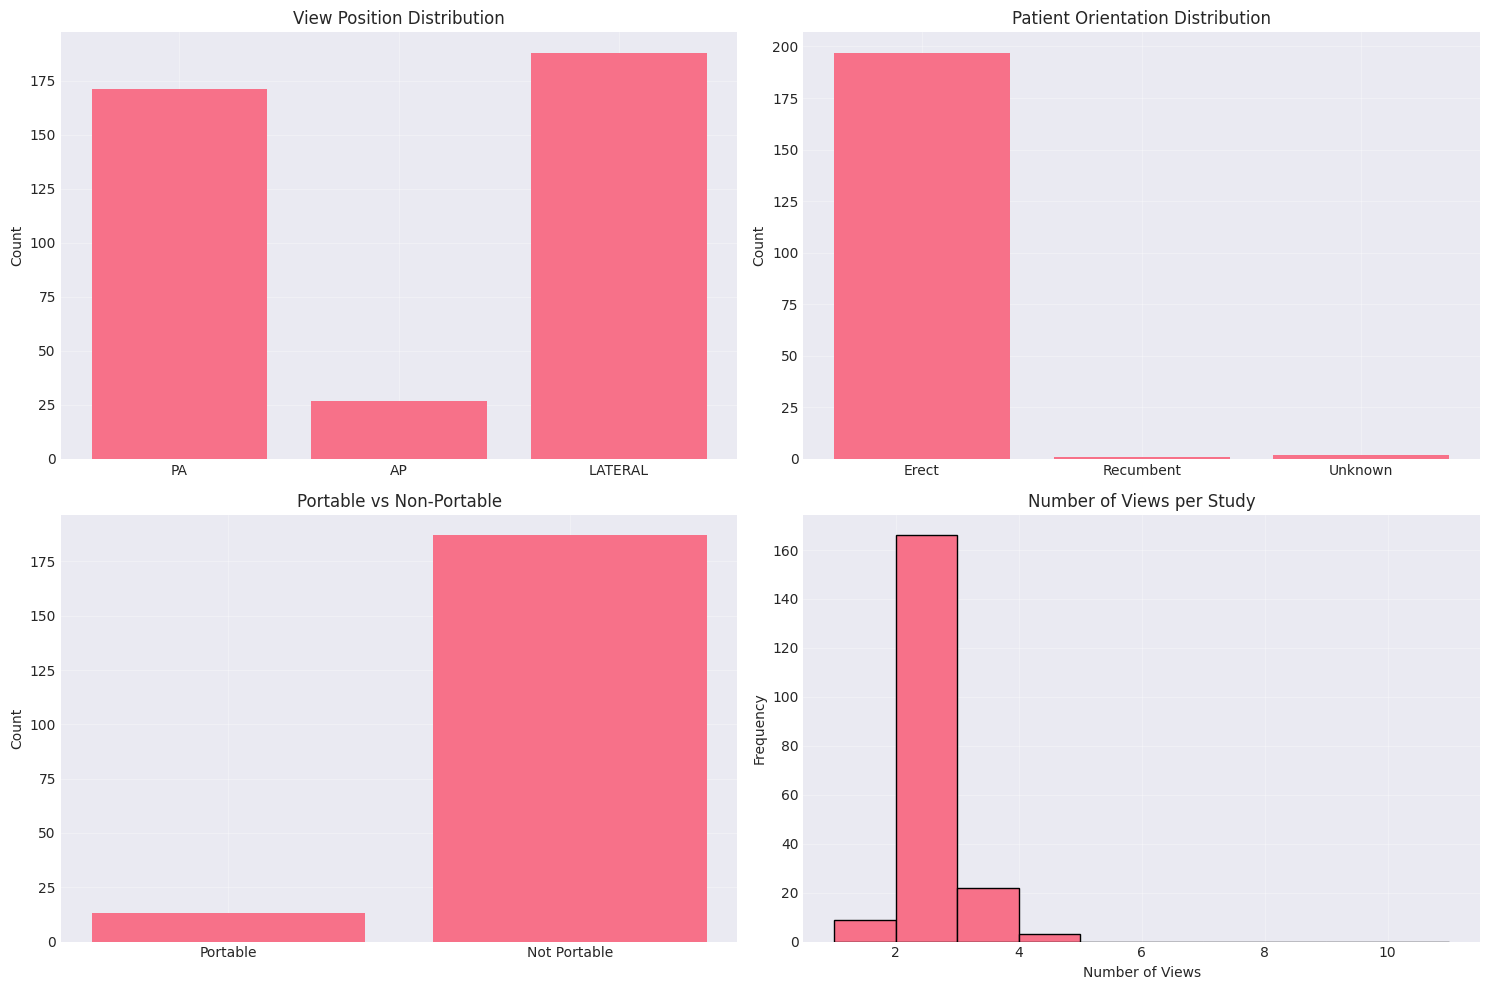

In [113]:
# Visualize DICOM metadata
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# View position distribution
view_counts = {
    'PA': sum([1 for v in dicom_values['view_pa'] if v == 1.0]),
    'AP': sum([1 for v in dicom_values['view_ap'] if v == 1.0]),
    'LATERAL': sum([1 for v in dicom_values['view_lateral'] if v == 1.0])
}
axes[0, 0].bar(view_counts.keys(), view_counts.values())
axes[0, 0].set_title('View Position Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3)

# Orientation distribution
orientation_counts = {
    'Erect': sum([1 for v in dicom_values['orientation_erect'] if v == 1.0]),
    'Recumbent': sum([1 for v in dicom_values['orientation_recumbent'] if v == 1.0]),
    'Unknown': sum([1 for v in dicom_values['orientation_unknown'] if v == 1.0])
}
axes[0, 1].bar(orientation_counts.keys(), orientation_counts.values())
axes[0, 1].set_title('Patient Orientation Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

# Portable detection
portable_counts = {
    'Portable': sum([1 for v in dicom_values['is_portable'] if v == 1.0]),
    'Not Portable': sum([1 for v in dicom_values['is_portable'] if v == 0.0])
}
axes[1, 0].bar(portable_counts.keys(), portable_counts.values())
axes[1, 0].set_title('Portable vs Non-Portable')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3)

# Number of views distribution
axes[1, 1].hist([v for v in dicom_values['num_views'] if v is not None], bins=range(1, 12), edgecolor='black')
axes[1, 1].set_title('Number of Views per Study')
axes[1, 1].set_xlabel('Number of Views')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [114]:
# Analyze vital signs coverage - CORRECTED FIELD NAMES
vital_fields = [
    'vital_temperature', 'vital_heartrate', 'vital_resprate',  # Fixed: heartrate, resprate (no underscores!)
    'vital_o2sat', 'vital_sbp', 'vital_dbp'
]

lab_fields = [
    'lab_wbc', 'lab_hemoglobin', 'lab_hematocrit', 'lab_platelets',
    'lab_sodium', 'lab_potassium', 'lab_chloride', 'lab_bicarbonate',
    'lab_bun', 'lab_creatinine', 'lab_glucose'
]

vital_coverage = {field: {'present': 0, 'missing': 0, 'values': []} for field in vital_fields}
lab_coverage = {field: {'present': 0, 'missing': 0, 'values': []} for field in lab_fields}

for item in structured_features:
    data = item['data']
    
    # Process vital signs
    for field in vital_fields:
        if field in data and isinstance(data[field], dict):
            is_missing = data[field].get('is_missing', True)
            measurement_count = data[field].get('measurement_count', 0)
            mean_value = data[field].get('mean_value', 0.0)
            
            if is_missing or measurement_count == 0:
                vital_coverage[field]['missing'] += 1
            else:
                vital_coverage[field]['present'] += 1
                # Store the mean value (not last/first value)
                if mean_value != 0.0:
                    vital_coverage[field]['values'].append(mean_value)
    
    # Process lab values
    for field in lab_fields:
        if field in data and isinstance(data[field], dict):
            is_missing = data[field].get('is_missing', True)
            measurement_count = data[field].get('measurement_count', 0)
            mean_value = data[field].get('mean_value', 0.0)
            
            if is_missing or measurement_count == 0:
                lab_coverage[field]['missing'] += 1
            else:
                lab_coverage[field]['present'] += 1
                if mean_value != 0.0:
                    lab_coverage[field]['values'].append(mean_value)

print("\n❤️  Vital Signs Coverage:")
print("="*60)
for field, counts in vital_coverage.items():
    total = counts['present'] + counts['missing']
    pct = counts['present'] / total * 100 if total > 0 else 0
    field_display = field.replace('vital_', '').replace('_', ' ').title()
    print(f"   {field_display:20s}: {counts['present']:3d}/{total} ({pct:5.1f}%)", end="")
    if counts['values']:
        mean_val = np.mean(counts['values'])
        std_val = np.std(counts['values'])
        print(f"  →  Mean: {mean_val:6.1f} ± {std_val:5.1f} (n={len(counts['values'])})")
    else:
        print("  →  No data")

print(f"\n🧪 Lab Values Coverage:")
print("="*60)
for field, counts in lab_coverage.items():
    total = counts['present'] + counts['missing']
    pct = counts['present'] / total * 100 if total > 0 else 0
    field_display = field.replace('lab_', '').replace('_', ' ').title()
    print(f"   {field_display:20s}: {counts['present']:3d}/{total} ({pct:5.1f}%)", end="")
    if counts['values']:
        mean_val = np.mean(counts['values'])
        std_val = np.std(counts['values'])
        print(f"  →  Mean: {mean_val:6.1f} ± {std_val:5.1f} (n={len(counts['values'])})")
    else:
        print("  →  No data")

# Summary statistics
vital_present_total = sum(c['present'] for c in vital_coverage.values())
vital_total = sum(c['present'] + c['missing'] for c in vital_coverage.values())
lab_present_total = sum(c['present'] for c in lab_coverage.values())
lab_total = sum(c['present'] + c['missing'] for c in lab_coverage.values())

print(f"\n📊 Overall Coverage:")
print(f"   Vitals: {vital_present_total}/{vital_total} ({vital_present_total/vital_total*100:.1f}%)")
print(f"   Labs:   {lab_present_total}/{lab_total} ({lab_present_total/lab_total*100:.1f}%)")


❤️  Vital Signs Coverage:
   Temperature         : 143/200 ( 71.5%)  →  Mean:   98.3 ±   1.0 (n=143)
   Heartrate           : 152/200 ( 76.0%)  →  Mean:   82.5 ±  15.9 (n=152)
   Resprate            : 151/200 ( 75.5%)  →  Mean:   17.5 ±   2.5 (n=151)
   O2Sat               : 148/200 ( 74.0%)  →  Mean:   98.3 ±   1.8 (n=148)
   Sbp                 : 151/200 ( 75.5%)  →  Mean:  131.6 ±  15.9 (n=151)
   Dbp                 : 151/200 ( 75.5%)  →  Mean:   76.9 ±  11.3 (n=151)

🧪 Lab Values Coverage:
   Wbc                 :   0/200 (  0.0%)  →  No data
   Hemoglobin          :   7/200 (  3.5%)  →  Mean:   13.0 ±   1.7 (n=7)
   Hematocrit          :   7/200 (  3.5%)  →  Mean:   38.9 ±   4.5 (n=7)
   Platelets           :   0/200 (  0.0%)  →  No data
   Sodium              :   6/200 (  3.0%)  →  Mean:  138.8 ±   2.5 (n=6)
   Potassium           :   6/200 (  3.0%)  →  Mean:    4.0 ±   0.3 (n=6)
   Chloride            :   6/200 (  3.0%)  →  Mean:  102.3 ±   2.7 (n=6)
   Bicarbonate         :  

In [115]:
# LAB FIX VERIFICATION - Check if charttime bug fix is working
print("\n" + "="*70)
print("🔬 LAB DATA FIX VERIFICATION")
print("="*70)

# Count samples by lab data source
samples_with_lab_via_hadm = 0
samples_with_lab_via_subject = 0
samples_with_any_lab = 0

# Also check for debug messages in structured features
for item in structured_features:
    data = item['data']
    
    # Check if sample has any lab data
    has_any_lab = any(
        field in data and 
        isinstance(data[field], dict) and 
        not data[field].get('is_missing', True) and
        data[field].get('measurement_count', 0) > 0
        for field in lab_fields
    )
    
    if has_any_lab:
        samples_with_any_lab += 1

# Load cohort to check hadm_id distribution
cohort_check = pd.read_csv(COHORT_PATH)
cohort_check['sample_id'] = 's' + cohort_check['subject_id'].astype(str) + '_study' + cohort_check['study_id'].astype(str)

with_hadm = cohort_check['hadm_id'].notna().sum()
without_hadm = cohort_check['hadm_id'].isna().sum()

print(f"\n📋 Cohort Breakdown:")
print(f"   Total samples: {len(cohort_check)}")
print(f"   Samples WITH hadm_id: {with_hadm} ({with_hadm/len(cohort_check)*100:.1f}%)")
print(f"   Samples WITHOUT hadm_id: {without_hadm} ({without_hadm/len(cohort_check)*100:.1f}%)")

print(f"\n🧪 Lab Data Results:")
print(f"   Samples with ANY lab data: {samples_with_any_lab}/{len(structured_features)} ({samples_with_any_lab/len(structured_features)*100:.1f}%)")

if samples_with_any_lab == 0:
    print(f"\n❌ NO LAB DATA FOUND")
    print(f"   Expected: At least some samples should have lab data")
    print(f"   Possible reasons:")
    print(f"     1. charttime bug not fixed (check temporal_processor.py line 290)")
    print(f"     2. Lab events filtered out in validation subset")
    print(f"     3. Time window mismatch between ED visits and lab chartimes")
    print(f"     4. 'No Finding' patients typically have fewer/no labs ordered")
else:
    print(f"\n✅ LAB FIX WORKING")
    print(f"   {samples_with_any_lab} samples have lab data")
    
    # Show which labs are most common
    lab_type_counts = {field: 0 for field in lab_fields}
    for item in structured_features:
        data = item['data']
        for field in lab_fields:
            if field in data and isinstance(data[field], dict):
                if not data[field].get('is_missing', True) and data[field].get('measurement_count', 0) > 0:
                    lab_type_counts[field] += 1
    
    print(f"\n   Lab type distribution:")
    for field, count in sorted(lab_type_counts.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            field_name = field.replace('lab_', '').upper()
            print(f"     - {field_name}: {count} samples ({count/len(structured_features)*100:.1f}%)")

print("="*70)


🔬 LAB DATA FIX VERIFICATION

📋 Cohort Breakdown:
   Total samples: 200
   Samples WITH hadm_id: 52 (26.0%)
   Samples WITHOUT hadm_id: 148 (74.0%)

🧪 Lab Data Results:
   Samples with ANY lab data: 7/200 (3.5%)

✅ LAB FIX WORKING
   7 samples have lab data

   Lab type distribution:
     - HEMOGLOBIN: 7 samples (3.5%)
     - HEMATOCRIT: 7 samples (3.5%)
     - SODIUM: 6 samples (3.0%)
     - POTASSIUM: 6 samples (3.0%)
     - CHLORIDE: 6 samples (3.0%)
     - BICARBONATE: 6 samples (3.0%)
     - CREATININE: 6 samples (3.0%)
     - GLUCOSE: 6 samples (3.0%)


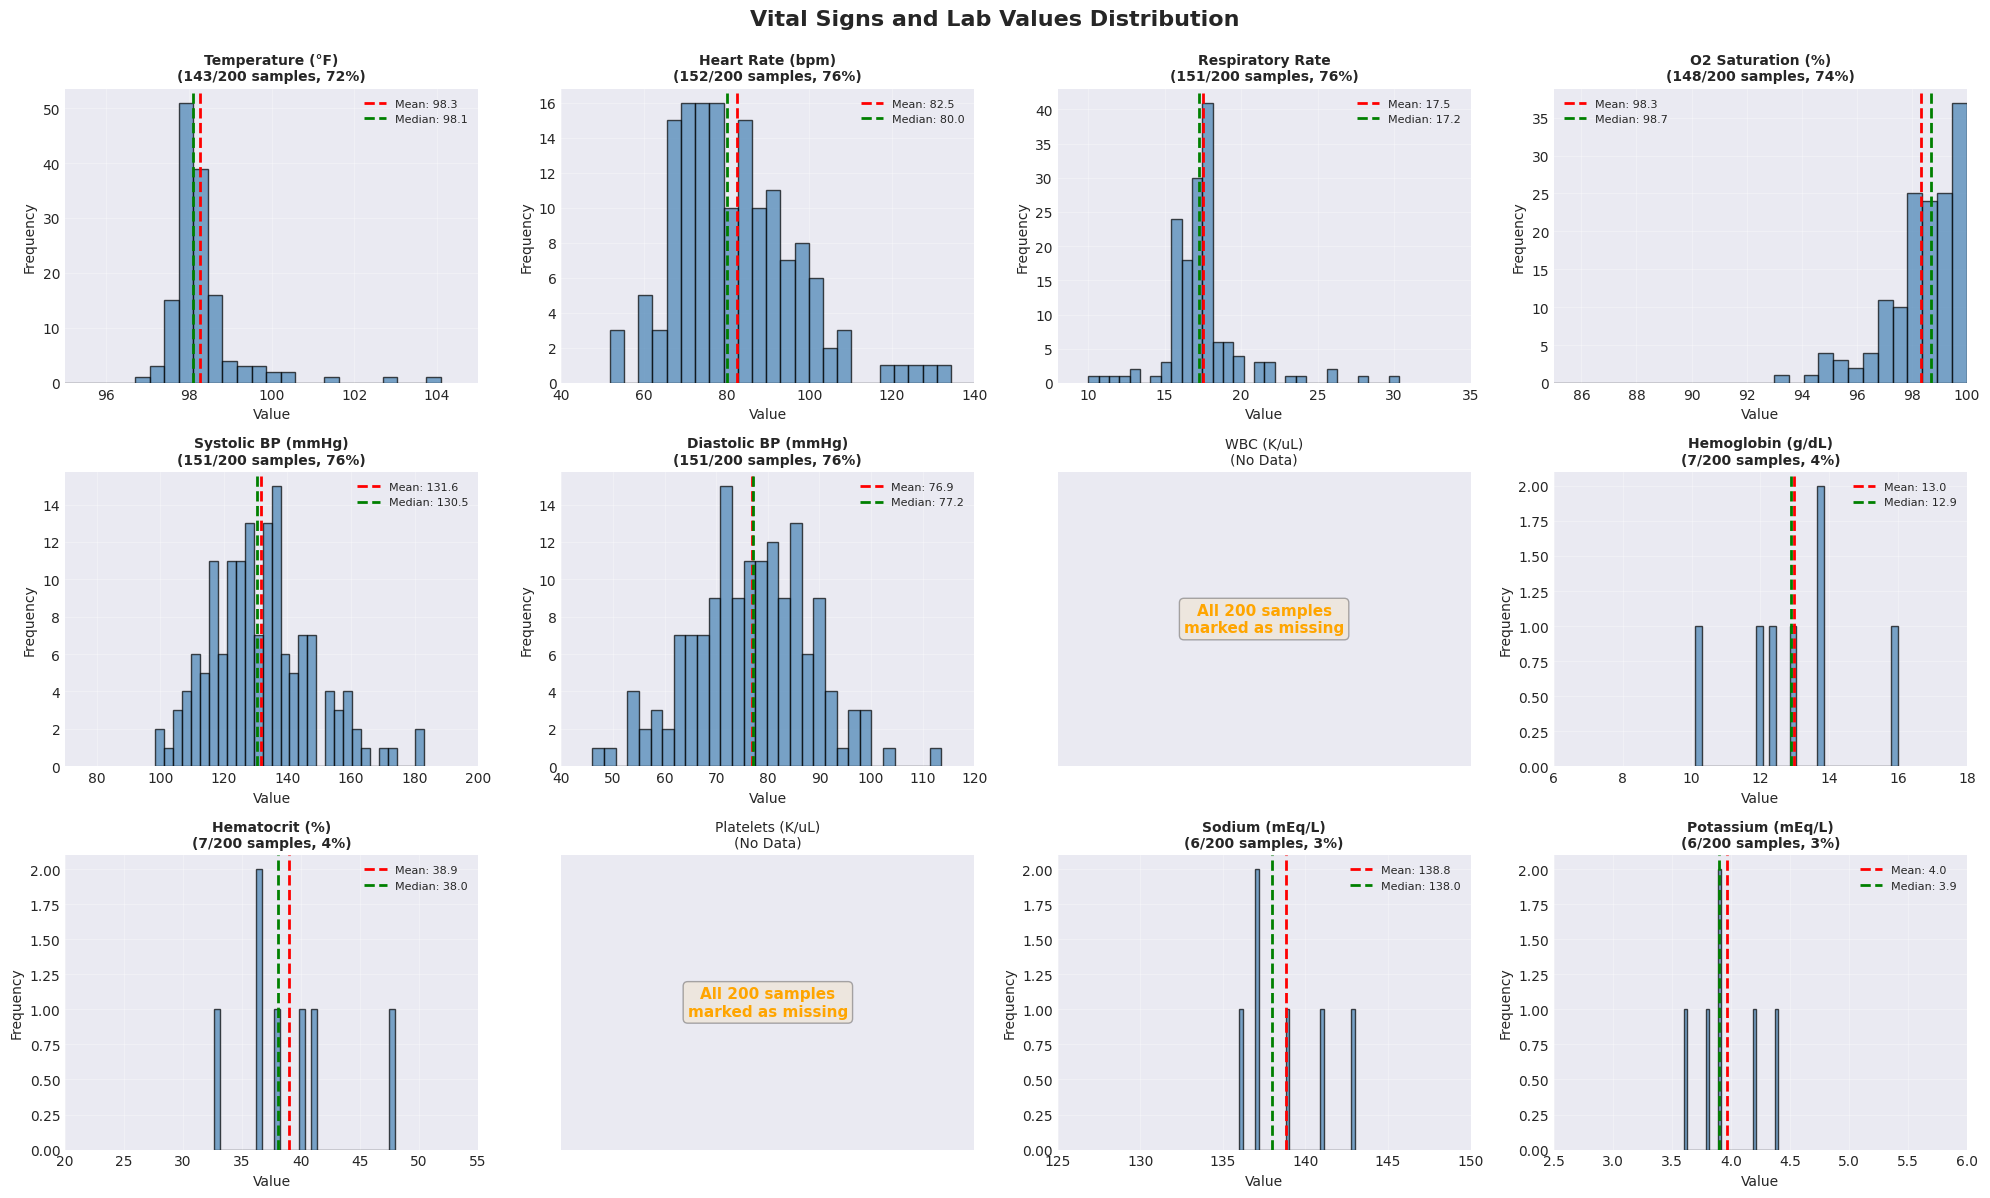


VITAL SIGNS & LAB VALUES SUMMARY

✅ Vital Signs: 6/6 types have data
✅ Lab Values:  8/11 types have data


In [116]:
# Visualize vital signs and lab values distribution
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

vital_labels = {
    'vital_temperature': ('Temperature (°F)', 95, 105),
    'vital_heartrate': ('Heart Rate (bpm)', 40, 140),
    'vital_resprate': ('Respiratory Rate', 8, 35),
    'vital_o2sat': ('O2 Saturation (%)', 85, 100),
    'vital_sbp': ('Systolic BP (mmHg)', 70, 200),
    'vital_dbp': ('Diastolic BP (mmHg)', 40, 120)
}

lab_labels = {
    'lab_wbc': ('WBC (K/uL)', 0, 20),
    'lab_hemoglobin': ('Hemoglobin (g/dL)', 6, 18),
    'lab_hematocrit': ('Hematocrit (%)', 20, 55),
    'lab_platelets': ('Platelets (K/uL)', 0, 500),
    'lab_sodium': ('Sodium (mEq/L)', 125, 150),
    'lab_potassium': ('Potassium (mEq/L)', 2.5, 6)
}

all_fields = list(vital_labels.items()) + list(lab_labels.items())
has_any_data = False

for idx, (field, (label, range_min, range_max)) in enumerate(all_fields):
    if idx >= len(axes):
        break
    
    # Get values from appropriate coverage dict
    if field in vital_coverage:
        values = vital_coverage[field]['values']
        total = vital_coverage[field]['present'] + vital_coverage[field]['missing']
        present = vital_coverage[field]['present']
    else:
        values = lab_coverage[field]['values']
        total = lab_coverage[field]['present'] + lab_coverage[field]['missing']
        present = lab_coverage[field]['present']
    
    if values and len(values) > 0:
        has_any_data = True
        # Plot histogram with statistics
        axes[idx].hist(values, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].axvline(np.mean(values), color='red', linestyle='--', linewidth=2,
                         label=f'Mean: {np.mean(values):.1f}')
        axes[idx].axvline(np.median(values), color='green', linestyle='--', linewidth=2,
                         label=f'Median: {np.median(values):.1f}')
        axes[idx].set_title(f'{label}\n({present}/{total} samples, {present/total*100:.0f}%)', 
                           fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        
        # Add range reference lines if available
        if range_min and range_max:
            axes[idx].set_xlim(range_min, range_max)
    else:
        # Show informative message about why there's no data
        if total == 0:
            message = 'Field not present\nin dataset'
            color = 'gray'
        else:
            message = f'All {total} samples\nmarked as missing'
            color = 'orange'
        
        axes[idx].text(0.5, 0.5, message, ha='center', va='center', 
                      fontsize=11, color=color, fontweight='bold',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        axes[idx].set_title(f'{label}\n(No Data)', fontsize=10)
        axes[idx].set_xlim(0, 1)
        axes[idx].set_ylim(0, 1)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])

# Hide unused subplots
for idx in range(len(all_fields), len(axes)):
    axes[idx].axis('off')

# Add overall title
fig.suptitle('Vital Signs and Lab Values Distribution', 
            fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("VITAL SIGNS & LAB VALUES SUMMARY")
print("="*70)

vital_with_data = sum(1 for c in vital_coverage.values() if len(c['values']) > 0)
lab_with_data = sum(1 for c in lab_coverage.values() if len(c['values']) > 0)

print(f"\n✅ Vital Signs: {vital_with_data}/6 types have data")
print(f"✅ Lab Values:  {lab_with_data}/11 types have data")

if lab_with_data == 0:
    print("\n⚠️  NOTE: No lab data found in this dataset.")
    print("   This is expected if the preprocessing didn't include MIMIC-IV labevents.")

In [117]:
# Sample structured features to show detailed data structure
print("\n📝 Sample Structured Feature Records:")
print("="*80)

# Find samples with vital signs data
samples_with_vitals = []
for item in structured_features:
    data = item['data']
    for field in vital_fields:
        if field in data and isinstance(data[field], dict):
            if not data[field].get('is_missing', True):
                samples_with_vitals.append(item)
                break

# Show 3 samples with vital signs
for i, item in enumerate(samples_with_vitals[:3]):
    data = item['data']
    print(f"\nSample {i+1}: {item['file']}")
    print("-" * 80)
    
    # Show DICOM metadata
    print("  DICOM Metadata:")
    dicom_fields = ['view_pa', 'view_ap', 'view_lateral', 'orientation_erect', 
                    'orientation_recumbent', 'is_portable', 'num_views']
    for field in dicom_fields:
        if field in data:
            print(f"    {field:25s}: {data[field]}")
    
    # Show vital signs with data
    print("\n  Vital Signs:")
    for field in vital_fields:
        if field in data and isinstance(data[field], dict):
            vdata = data[field]
            if not vdata.get('is_missing', True):
                field_name = field.replace('vital_', '').replace('_', ' ').title()
                print(f"    {field_name:25s}:", end="")
                print(f" Mean={vdata.get('mean_value', 0):.1f},", end="")
                print(f" Min={vdata.get('min_value', 0):.1f},", end="")
                print(f" Max={vdata.get('max_value', 0):.1f},", end="")
                print(f" Count={vdata.get('measurement_count', 0)}")

print("\n" + "="*80)


📝 Sample Structured Feature Records:

Sample 1: s10167294_study57419506
--------------------------------------------------------------------------------
  DICOM Metadata:
    view_pa                  : 1.0
    view_ap                  : 0.0
    view_lateral             : 1.0
    orientation_erect        : 1.0
    orientation_recumbent    : 0.0
    is_portable              : 0.0
    num_views                : 2.0

  Vital Signs:
    Temperature              : Mean=98.1, Min=98.1, Max=98.1, Count=1
    Heartrate                : Mean=70.0, Min=70.0, Max=70.0, Count=1
    Resprate                 : Mean=16.0, Min=16.0, Max=16.0, Count=1
    O2Sat                    : Mean=99.0, Min=99.0, Max=99.0, Count=1
    Sbp                      : Mean=128.0, Min=128.0, Max=128.0, Count=1
    Dbp                      : Mean=88.0, Min=88.0, Max=88.0, Count=1

Sample 2: s10209685_study52420444
--------------------------------------------------------------------------------
  DICOM Metadata:
    view_p

## 6. Multimodal Completeness Analysis

In [118]:
# Analyze multimodal completeness
completeness = []

for meta in all_metadata:
    sample_id = f"s{meta['subject_id']}_study{meta['study_id']}"
    
    # Check if each modality exists
    has_image = (OUTPUT_DIR / 'images' / f"{sample_id}.pt").exists()
    has_text = (OUTPUT_DIR / 'text_features' / f"{sample_id}.pt").exists()
    has_structured = (OUTPUT_DIR / 'structured_features' / f"{sample_id}.json").exists()
    
    # Check if text is non-empty (more than 2 tokens)
    text_valid = False
    if has_text:
        text_data = torch.load(OUTPUT_DIR / 'text_features' / f"{sample_id}.pt")
        num_tokens = text_data['tokens']['num_tokens'] if 'tokens' in text_data and 'num_tokens' in text_data['tokens'] else len(text_data.get('tokens', {}).get('input_ids', []))
        text_valid = num_tokens > 2
    
    completeness.append({
        'sample_id': sample_id,
        'has_image': has_image,
        'has_text': has_text,
        'text_valid': text_valid,
        'has_structured': has_structured,
        'modality_count': sum([has_image, text_valid, has_structured]),
        'all_complete': has_image and text_valid and has_structured
    })

comp_df = pd.DataFrame(completeness)

print("\n🎯 Multimodal Completeness:")
print(f"   Total samples: {len(comp_df)}")
print(f"   Image modality: {comp_df['has_image'].sum()} ({comp_df['has_image'].sum()/len(comp_df)*100:.1f}%)")
print(f"   Text modality (valid): {comp_df['text_valid'].sum()} ({comp_df['text_valid'].sum()/len(comp_df)*100:.1f}%)")
print(f"   Structured modality: {comp_df['has_structured'].sum()} ({comp_df['has_structured'].sum()/len(comp_df)*100:.1f}%)")
print(f"\n   Complete samples (all 3 modalities): {comp_df['all_complete'].sum()} ({comp_df['all_complete'].sum()/len(comp_df)*100:.1f}%)")

# Modality count distribution
modality_counts = comp_df['modality_count'].value_counts().sort_index()
print("\n   Samples by modality count:")
for count, num_samples in modality_counts.items():
    print(f"      {count} modalities: {num_samples} samples ({num_samples/len(comp_df)*100:.1f}%)")


🎯 Multimodal Completeness:
   Total samples: 200
   Image modality: 200 (100.0%)
   Text modality (valid): 171 (85.5%)
   Structured modality: 200 (100.0%)

   Complete samples (all 3 modalities): 171 (85.5%)

   Samples by modality count:
      2 modalities: 29 samples (14.5%)
      3 modalities: 171 samples (85.5%)


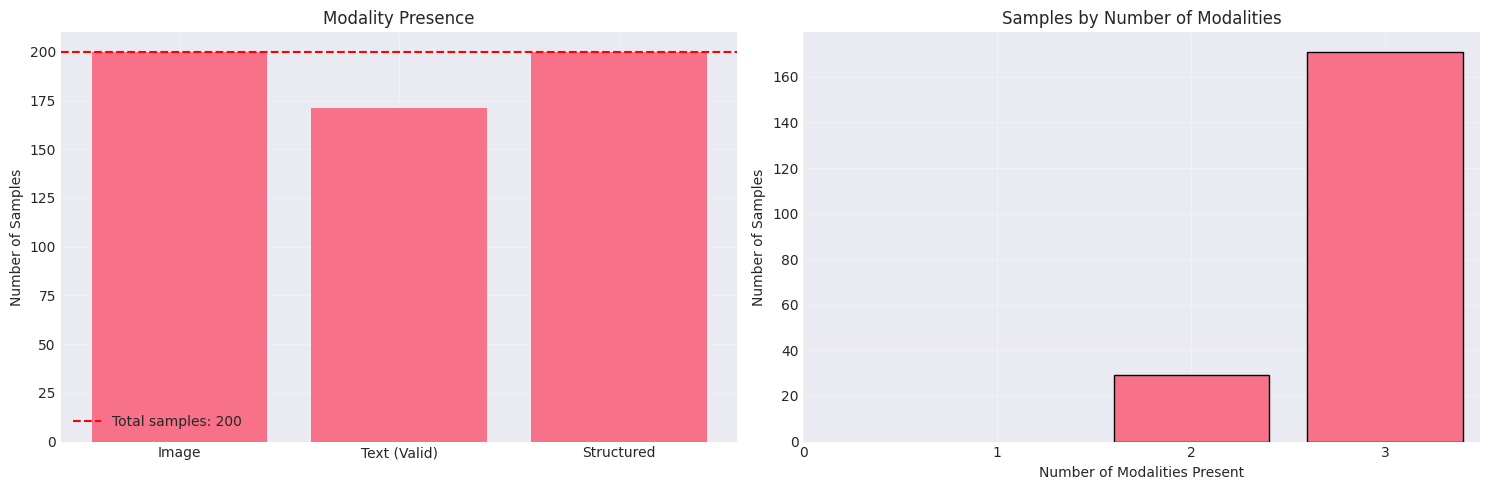

In [119]:
# Visualize multimodal completeness
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Modality presence
modality_presence = {
    'Image': comp_df['has_image'].sum(),
    'Text (Valid)': comp_df['text_valid'].sum(),
    'Structured': comp_df['has_structured'].sum()
}
axes[0].bar(modality_presence.keys(), modality_presence.values())
axes[0].axhline(len(comp_df), color='red', linestyle='--', label=f'Total samples: {len(comp_df)}')
axes[0].set_title('Modality Presence')
axes[0].set_ylabel('Number of Samples')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Completeness distribution
axes[1].bar(modality_counts.index, modality_counts.values, edgecolor='black')
axes[1].set_title('Samples by Number of Modalities')
axes[1].set_xlabel('Number of Modalities Present')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xticks([0, 1, 2, 3])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Identify potential issues
print("🔍 Quality Checks:\n")

# 1. Empty text features
empty_text = text_df[text_df['num_tokens'] <= 2]
print(f"1. Empty text features (≤2 tokens): {len(empty_text)} samples")
if len(empty_text) > 0:
    print(f"   Sample IDs: {empty_text['file'].head(5).tolist()}")

# 2. Missing summaries
no_summary = text_df[text_df['summary'].str.len() == 0]
print(f"\n2. Missing Claude summaries: {len(no_summary)} samples")

# 3. Unusual image shapes
shape_counts = image_df['shape'].value_counts()
if len(shape_counts) > 1:
    print(f"\n3. Multiple image shapes detected:")
    for shape, count in list(shape_counts.items())[:5]:  # Show top 5
        print(f"   {shape}: {count} images")
    if len(shape_counts) > 5:
        print(f"   ... and {len(shape_counts) - 5} more shapes")

# 4. Samples with no vitals (CORRECTED FIELD NAMES)
samples_with_vitals = 0
samples_with_labs = 0

for item in structured_features:
    data = item['data']
    
    # Check for any vital sign
    has_any_vital = any(
        field in data and 
        isinstance(data[field], dict) and 
        not data[field].get('is_missing', True) and
        data[field].get('measurement_count', 0) > 0
        for field in vital_fields  # Using corrected vital_fields from cell 21
    )
    if has_any_vital:
        samples_with_vitals += 1
    
    # Check for any lab value
    has_any_lab = any(
        field in data and 
        isinstance(data[field], dict) and 
        not data[field].get('is_missing', True) and
        data[field].get('measurement_count', 0) > 0
        for field in lab_fields  # Using lab_fields from cell 21
    )
    if has_any_lab:
        samples_with_labs += 1

no_vitals = len(structured_features) - samples_with_vitals
no_labs = len(structured_features) - samples_with_labs

print(f"\n4. Samples with vital signs: {samples_with_vitals}/{len(structured_features)} ({samples_with_vitals/len(structured_features)*100:.1f}%)")
print(f"   Samples WITHOUT vitals:   {no_vitals} ({no_vitals/len(structured_features)*100:.1f}%)")

print(f"\n5. Samples with lab values: {samples_with_labs}/{len(structured_features)} ({samples_with_labs/len(structured_features)*100:.1f}%)")
print(f"   Samples WITHOUT labs:    {no_labs} ({no_labs/len(structured_features)*100:.1f}%)")

# 6. Incomplete samples
incomplete = comp_df[~comp_df['all_complete']]
print(f"\n6. Incomplete samples (missing modalities): {len(incomplete)} ({len(incomplete)/len(comp_df)*100:.1f}%)")

# Overall data quality summary
print("\n" + "="*70)
print("OVERALL DATA QUALITY")
print("="*70)
quality_score = 0
max_score = 5

if (text_df['num_tokens'] > 2).sum() / len(text_df) >= 0.8:
    quality_score += 1
    print("✅ Text quality: GOOD (>80% valid)")
else:
    print("⚠️  Text quality: NEEDS IMPROVEMENT (<80% valid)")

if len(shape_counts) == 1:
    quality_score += 1
    print("✅ Image uniformity: GOOD (single shape)")
elif len(shape_counts) <= 5:
    quality_score += 1
    print("⚠️  Image uniformity: ACCEPTABLE (few variations)")
else:
    print("⚠️  Image uniformity: POOR (many variations)")

if samples_with_vitals / len(structured_features) >= 0.5:
    quality_score += 1
    print(f"✅ Vital signs coverage: GOOD ({samples_with_vitals/len(structured_features)*100:.0f}%)")
elif samples_with_vitals / len(structured_features) >= 0.3:
    quality_score += 0.5
    print(f"⚠️  Vital signs coverage: MODERATE ({samples_with_vitals/len(structured_features)*100:.0f}%)")
else:
    print(f"❌ Vital signs coverage: POOR ({samples_with_vitals/len(structured_features)*100:.0f}%)")

if comp_df['all_complete'].sum() / len(comp_df) >= 0.8:
    quality_score += 1
    print("✅ Multimodal completeness: GOOD (>80%)")
else:
    print("⚠️  Multimodal completeness: NEEDS IMPROVEMENT (<80%)")

if len(error_free_samples) / len(all_metadata) >= 0.95:
    quality_score += 1
    print("✅ Error rate: EXCELLENT (<5% errors)")
else:
    print("⚠️  Error rate: NEEDS ATTENTION (≥5% errors)")

print(f"\n📊 Overall Quality Score: {quality_score:.1f}/{max_score} ({quality_score/max_score*100:.0f}%)")

In [120]:
# Identify potential issues
print("🔍 Quality Checks:\n")

# 1. Empty text features
empty_text = text_df[text_df['num_tokens'] <= 2]
print(f"1. Empty text features (≤2 tokens): {len(empty_text)} samples")
if len(empty_text) > 0:
    print(f"   Sample IDs: {empty_text['file'].head(5).tolist()}")

# 2. Missing summaries
no_summary = text_df[text_df['summary'].str.len() == 0]
print(f"\n2. Missing Claude summaries: {len(no_summary)} samples")

# 3. Unusual image shapes
shape_counts = image_df['shape'].value_counts()
if len(shape_counts) > 1:
    print(f"\n3. Multiple image shapes detected:")
    for shape, count in shape_counts.items():
        print(f"   {shape}: {count} images")

# 4. Samples with no vitals
no_vitals = 0
for item in structured_features:
    data = item['data']
    has_any_vital = any(
        field in data and 
        isinstance(data[field], dict) and 
        not data[field].get('is_missing', True) and 
        data[field].get('value') != 'NOT_DONE'
        for field in vital_fields
    )
    if not has_any_vital:
        no_vitals += 1

print(f"\n4. Samples with no vital signs: {no_vitals} ({no_vitals/len(structured_features)*100:.1f}%)")

# 5. Incomplete samples
incomplete = comp_df[~comp_df['all_complete']]
print(f"\n5. Incomplete samples (missing modalities): {len(incomplete)} ({len(incomplete)/len(comp_df)*100:.1f}%)")

🔍 Quality Checks:

1. Empty text features (≤2 tokens): 29 samples
   Sample IDs: ['s10292305_study57592555', 's10297650_study50668000', 's11182413_study52055900', 's11504637_study55266525', 's11812637_study53413627']

2. Missing Claude summaries: 29 samples

3. Multiple image shapes detected:
   (1, 3056, 2544): 152 images
   (1, 2544, 3056): 27 images
   (1, 3056, 2504): 2 images
   (1, 2865, 2544): 1 images
   (1, 3028, 2544): 1 images
   (1, 2862, 2381): 1 images
   (1, 2860, 2484): 1 images
   (1, 3056, 2537): 1 images
   (1, 3056, 2512): 1 images
   (1, 2843, 2237): 1 images
   (1, 3056, 2536): 1 images
   (1, 3012, 2544): 1 images
   (1, 3011, 2428): 1 images
   (1, 3056, 2520): 1 images
   (1, 1688, 1791): 1 images
   (1, 2544, 3036): 1 images
   (1, 2637, 2417): 1 images
   (1, 3056, 2524): 1 images
   (1, 3056, 2320): 1 images
   (1, 3056, 2516): 1 images
   (1, 2540, 3056): 1 images
   (1, 2356, 2544): 1 images

4. Samples with no vital signs: 45 (22.5%)

5. Incomplete sample

In [121]:
# Correlation analysis (if cohort loaded)
if cohort is not None:
    # Merge completeness with cohort demographics
    cohort['sample_id'] = 's' + cohort['subject_id'].astype(str) + '_study' + cohort['study_id'].astype(str)
    merged = cohort.merge(comp_df, on='sample_id', how='left')
    
    print("\n📊 Completeness by Demographics:\n")
    
    if 'gender' in merged.columns:
        by_gender = merged.groupby('gender')['all_complete'].agg(['sum', 'count', 'mean'])
        print("By Gender:")
        print(by_gender)
    
    if 'anchor_age' in merged.columns:
        # Age groups
        merged['age_group'] = pd.cut(merged['anchor_age'], bins=[0, 30, 45, 60, 75, 100], 
                                     labels=['18-30', '31-45', '46-60', '61-75', '76+'])
        by_age = merged.groupby('age_group')['all_complete'].agg(['sum', 'count', 'mean'])
        print("\nBy Age Group:")
        print(by_age)


📊 Completeness by Demographics:

By Gender:
        sum  count      mean
gender                      
F       102    118  0.864407
M        69     82  0.841463

By Age Group:
           sum  count      mean
age_group                      
18-30       37     44  0.840909
31-45       38     46  0.826087
46-60       48     57  0.842105
61-75       35     37  0.945946
76+         13     16  0.812500


## 8. Summary Report

In [122]:
# Generate comprehensive summary report
report = {
    'timestamp': datetime.now().isoformat(),
    'total_samples': int(len(all_metadata)),
    'overall_metrics': {
        'error_free_samples': int(len(error_free_samples)),
        'error_free_rate': float(len(error_free_samples) / len(all_metadata) if all_metadata else 0),
        'complete_multimodal_samples': int(comp_df['all_complete'].sum()),
        'complete_multimodal_rate': float(comp_df['all_complete'].sum() / len(comp_df) if len(comp_df) > 0 else 0),
        'samples_with_vitals': int(samples_with_vitals),
        'samples_with_labs': int(samples_with_labs)
    },
    'text_metrics': {
        'total': int(len(text_df)),
        'valid_text_rate': float((text_df['num_tokens'] > 2).sum() / len(text_df) if len(text_df) > 0 else 0),
        'mean_tokens': float(text_df['num_tokens'].mean()),
        'median_tokens': float(text_df['num_tokens'].median()),
        'mean_summary_length': float(text_df['summary_length'].mean()),
        'mean_entities': float(text_df['num_entities'].mean())
    },
    'image_metrics': {
        'total': int(len(image_df)),
        'unique_shapes': int(len(image_df['shape'].unique())),
        'mean_size_mb': float(image_df['size_mb'].mean()),
        'most_common_shape': str(image_df['shape'].mode()[0]) if len(image_df) > 0 else None
    },
    'structured_metrics': {
        'total': int(len(structured_features)),
        'dicom_coverage': {
            field: float(dicom_coverage[field] / len(structured_features) if structured_features else 0)
            for field in dicom_fields
        },
        'vital_coverage': {
            field: float(vital_coverage[field]['present'] / (vital_coverage[field]['present'] + vital_coverage[field]['missing']) 
            if (vital_coverage[field]['present'] + vital_coverage[field]['missing']) > 0 else 0)
            for field in vital_fields
        },
        'lab_coverage': {
            field: float(lab_coverage[field]['present'] / (lab_coverage[field]['present'] + lab_coverage[field]['missing']) 
            if (lab_coverage[field]['present'] + lab_coverage[field]['missing']) > 0 else 0)
            for field in lab_fields
        },
        'vital_stats': {
            field: {
                'mean': float(np.mean(vital_coverage[field]['values'])) if vital_coverage[field]['values'] else None,
                'std': float(np.std(vital_coverage[field]['values'])) if vital_coverage[field]['values'] else None,
                'count': int(len(vital_coverage[field]['values']))
            }
            for field in vital_fields
        }
    },
    'quality_flags': {
        'empty_text_count': int((text_df['num_tokens'] <= 2).sum()),
        'no_summary_count': int((text_df['summary'].str.len() == 0).sum()),
        'no_vitals_count': int(no_vitals),
        'no_labs_count': int(no_labs),
        'incomplete_samples': int((~comp_df['all_complete']).sum())
    }
}

# Save report
report_path = OUTPUT_DIR.parent / 'pipeline_analysis_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print("\n" + "="*80)
print("📋 PREPROCESSING PIPELINE ANALYSIS SUMMARY")
print("="*80)
print(f"\nTotal Samples: {report['total_samples']}")
print(f"\nOverall Success Rates:")
print(f"  - Error-free: {report['overall_metrics']['error_free_rate']:.1%}")
print(f"  - Complete multimodal: {report['overall_metrics']['complete_multimodal_rate']:.1%}")

print(f"\nText Features:")
print(f"  - Valid text rate: {report['text_metrics']['valid_text_rate']:.1%}")
print(f"  - Mean tokens: {report['text_metrics']['mean_tokens']:.1f}")
print(f"  - Mean summary length: {report['text_metrics']['mean_summary_length']:.0f} characters")

print(f"\nImage Features:")
print(f"  - Total images: {report['image_metrics']['total']}")
print(f"  - Mean size: {report['image_metrics']['mean_size_mb']:.2f} MB")
print(f"  - Unique shapes: {report['image_metrics']['unique_shapes']}")

print(f"\nStructured Features:")
print(f"  - DICOM metadata coverage: {np.mean(list(report['structured_metrics']['dicom_coverage'].values())):.1%}")
print(f"  - Samples with vitals: {report['overall_metrics']['samples_with_vitals']}/{report['total_samples']} ({report['overall_metrics']['samples_with_vitals']/report['total_samples']*100:.1f}%)")
print(f"  - Samples with labs: {report['overall_metrics']['samples_with_labs']}/{report['total_samples']} ({report['overall_metrics']['samples_with_labs']/report['total_samples']*100:.1f}%)")

# Show vital signs breakdown
vital_present_by_type = {field: vital_coverage[field]['present'] for field in vital_fields}
print(f"\n  Vital Signs Breakdown:")
for field, count in vital_present_by_type.items():
    field_name = field.replace('vital_', '').replace('_', ' ').title()
    print(f"    - {field_name}: {count}/{report['total_samples']} ({count/report['total_samples']*100:.1f}%)")

print(f"\nQuality Flags:")
print(f"  - Empty text: {report['quality_flags']['empty_text_count']} samples")
print(f"  - No vitals: {report['quality_flags']['no_vitals_count']} samples")
print(f"  - No labs: {report['quality_flags']['no_labs_count']} samples")
print(f"  - Incomplete: {report['quality_flags']['incomplete_samples']} samples")

print(f"\n✅ Report saved to: {report_path}")
print("="*80)

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'list'

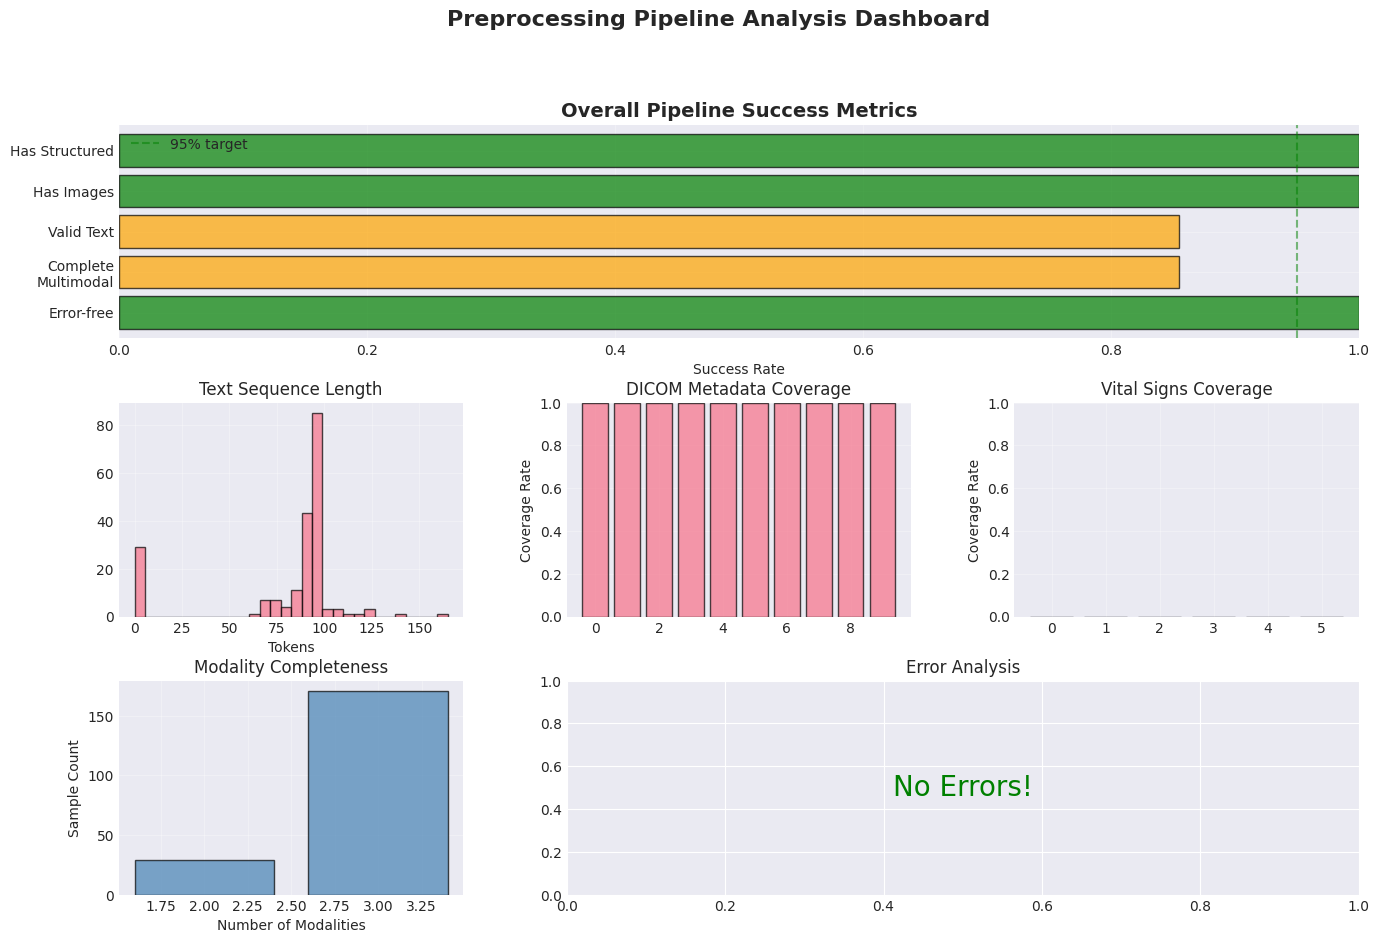


✅ Dashboard saved to: /home/ubuntu/mimic-cxr-validation/step2_preprocessing/output/validation_200/pipeline_analysis_dashboard.png


In [ ]:
# Final visualization: Summary dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Overall success rates
ax1 = fig.add_subplot(gs[0, :])
metrics = ['Error-free', 'Complete\nMultimodal', 'Valid Text', 'Has Images', 'Has Structured']
values = [
    report['overall_metrics']['error_free_rate'],
    report['overall_metrics']['complete_multimodal_rate'],
    report['text_metrics']['valid_text_rate'],
    len(image_df) / len(all_metadata) if all_metadata else 0,
    len(structured_features) / len(all_metadata) if all_metadata else 0
]
colors = ['green' if v >= 0.95 else 'orange' if v >= 0.8 else 'red' for v in values]
ax1.barh(metrics, values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlim(0, 1)
ax1.set_xlabel('Success Rate')
ax1.set_title('Overall Pipeline Success Metrics', fontsize=14, fontweight='bold')
ax1.axvline(0.95, color='green', linestyle='--', alpha=0.5, label='95% target')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Text tokens
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(text_df['num_tokens'], bins=30, edgecolor='black', alpha=0.7)
ax2.set_title('Text Sequence Length')
ax2.set_xlabel('Tokens')
ax2.grid(True, alpha=0.3)

# DICOM coverage
ax3 = fig.add_subplot(gs[1, 1])
dicom_cov_values = list(report['structured_metrics']['dicom_coverage'].values())
ax3.bar(range(len(dicom_cov_values)), dicom_cov_values, alpha=0.7, edgecolor='black')
ax3.set_title('DICOM Metadata Coverage')
ax3.set_ylabel('Coverage Rate')
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3)

# Vital signs coverage
ax4 = fig.add_subplot(gs[1, 2])
vital_cov_values = list(report['structured_metrics']['vital_coverage'].values())
ax4.bar(range(len(vital_cov_values)), vital_cov_values, alpha=0.7, edgecolor='black', color='coral')
ax4.set_title('Vital Signs Coverage')
ax4.set_ylabel('Coverage Rate')
ax4.set_ylim(0, 1)
ax4.grid(True, alpha=0.3)

# Modality completeness
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(modality_counts.index, modality_counts.values, alpha=0.7, edgecolor='black', color='steelblue')
ax5.set_title('Modality Completeness')
ax5.set_xlabel('Number of Modalities')
ax5.set_ylabel('Sample Count')
ax5.grid(True, alpha=0.3)

# Error types
ax6 = fig.add_subplot(gs[2, 1:])
if error_types:
    error_items = list(error_types.most_common(10))
    ax6.barh([e[0][:30] for e in error_items], [e[1] for e in error_items], alpha=0.7, edgecolor='black', color='salmon')
    ax6.set_title('Top 10 Error Types')
    ax6.set_xlabel('Count')
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'No Errors!', ha='center', va='center', fontsize=20, color='green')
    ax6.set_title('Error Analysis')

plt.suptitle('Preprocessing Pipeline Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(OUTPUT_DIR.parent / 'pipeline_analysis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Dashboard saved to: {OUTPUT_DIR.parent / 'pipeline_analysis_dashboard.png'}")